# 미추홀구 상권 활성화 분석 · 인하대 후문
2026.09.16 · 진행 현황과 분석 계획



In [3]:
from pathlib import Path
import json, hashlib, re, tempfile, os
import numpy as np
import pandas as pd
os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir())/'inha-meeting-mpl'))
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display, Markdown, HTML

ROOT = Path.cwd()
if not (ROOT/'data/raw/district_stores.json').exists():
    raise FileNotFoundError('Commercial district analysis 프로젝트 루트에서 실행하세요.')
OUT = ROOT/'outputs/meeting_20260916'
SAMPLES = OUT/'samples'
SAMPLES.mkdir(parents=True, exist_ok=True)
for font in ['AppleGothic','Malgun Gothic','NanumGothic']:
    if any(f.name == font for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = font
        break
plt.rcParams.update({'axes.unicode_minus':False,'figure.dpi':120})
pd.set_option('display.max_columns',20)
pd.set_option('display.max_colwidth',70)

stores_meta = json.loads((ROOT/'data/raw/district_stores.json').read_text())
district = pd.DataFrame(stores_meta['rows'])
stores = pd.read_csv(ROOT/'outputs/inha/stores.csv',dtype={'bizesId':str,'adongCd':str})
dong = district[district.adongCd.astype(str).eq('28177540')].copy()
outside = dong[~dong.bizesId.astype(str).isin(stores.bizesId)]
boundary = json.loads((ROOT/'data/inha_boundary.geojson').read_text())
audit = json.loads((ROOT/'data/raw/dsz_catalog_sample_audit_20260915.json').read_text())
products = {p['id']:p for p in audit['products']}
assert stores.bizesId.is_unique and district.bizesId.is_unique
assert len(stores)==534 and len(dong)==1349 and len(outside)==815
assert len(products)==23 and all(len(p['samples'])==10 for p in products.values())
attachments = []

def table(frame):
    display(HTML(frame.to_html(index=False,border=0,float_format=lambda x:f'{x:,.2f}')))

def attach(frame, filename, title, source_url, source_file, period, status, selection):
    path = SAMPLES/filename
    frame.to_csv(path,index=False,encoding='utf-8-sig')
    attachments.append(dict(file='samples/'+filename,title=title,rows=len(frame),
        period=period,status=status,selection=selection,source_url=source_url,
        source_file=source_file,source_sha256=hashlib.sha256((ROOT/source_file).read_bytes()).hexdigest(),
        sample_sha256=hashlib.sha256(path.read_bytes()).hexdigest()))
    return frame

def figure_done(fig, name):
    fig.tight_layout()
    fig.savefig(OUT/name,dpi=150,bbox_inches='tight')
    plt.show()


## 1. 진행 현황

| 작업 | 현재 상태 | 목적에 대한 기여 |
|---|---|---|
| 미추홀구 점포 수집·정제 | 2026.06 제공자료 18,885개 | 업종·위치 기준자료 |
| 후보 상권 EDA·미팅 | 인하대 후문 선정 | 상세 분석 대상 확정 |
| 사용자 경계 적용 | 경계 내부 534개, 약 13.74ha | 조사·전략 적용 범위 |
| 버스·주민인구 연결 | 버스 2026.06, 위치 2025.10 / 인구 2026.06·08 | 교통 여건·배후 주민 |
| 학사일정 수집 | 2024~2026 | 소비 변동을 설명할 보조자료 |
| 카드·유동 상품 조사 | 23개 명세와 공개 미리보기 230행 확인 | 신청할 데이터 선택 |
| 현장조사 | 계획·빈 서식 준비 | 아직 관측 결과 없음 |

활성화는 **기존 강점 확대·이용 불편 해소·부진 대응**을 모두 포함한다. 쇠퇴를 미리 전제하지 않는다.


## 2. 상권 현황과 분석 단위

**후문은 음식점 비중이 높은 공간이다. 그러나 이것만으로 과밀이나 쇠퇴를 판단할 수는 없다.**

공식 상권 경계가 아니며, 포함·제외 이유와 실제 점포 입구를 답사에서 확인해야 한다.


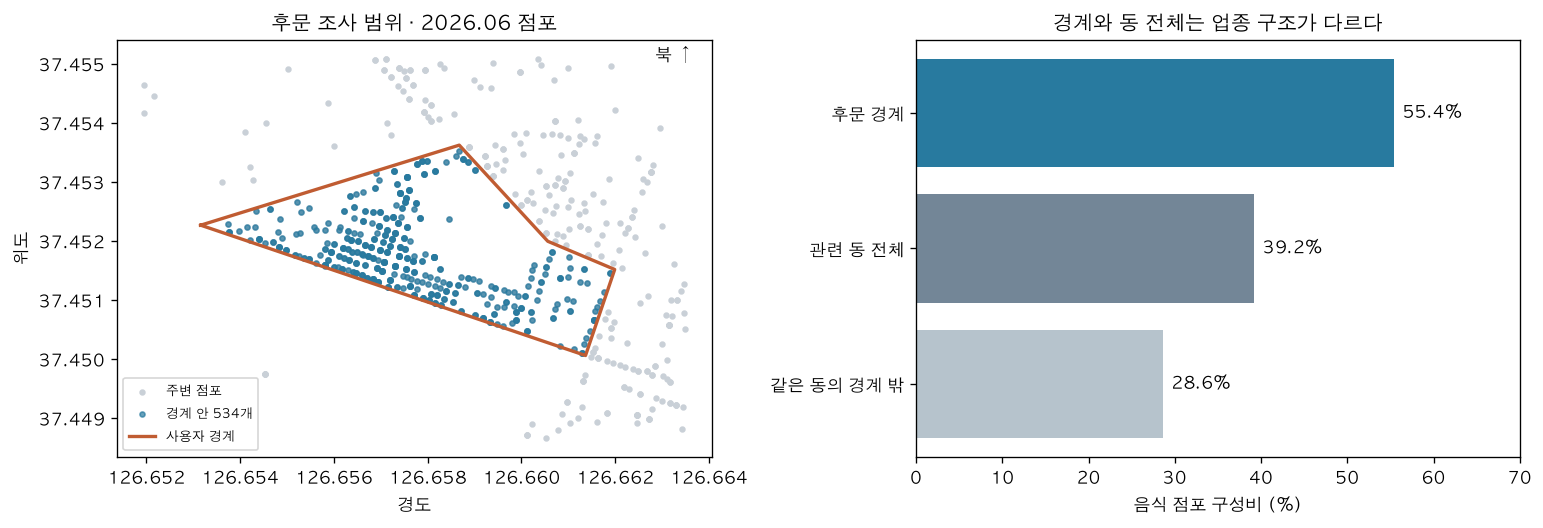

범위,전체 점포,음식 점포,음식 비중(%)
후문 경계,534,296,55.40
관련 동 전체,1349,529,39.20
같은 동의 경계 밖,815,233,28.60


In [4]:
feature = boundary['features'][0] if boundary.get('type')=='FeatureCollection' else boundary
ring = np.array(feature['geometry']['coordinates'][0],dtype=float)
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
near = district[(district.lon.between(ring[:,0].min()-.0015,ring[:,0].max()+.0015)) &
                (district.lat.between(ring[:,1].min()-.0015,ring[:,1].max()+.0015))]
axes[0].scatter(near.lon,near.lat,s=8,color='#c9d0d7',label='주변 점포')
axes[0].scatter(stores.lon,stores.lat,s=9,color='#287a9f',alpha=.7,label='경계 안 534개')
axes[0].plot(ring[:,0],ring[:,1],color='#c05c32',lw=2,label='사용자 경계')
axes[0].set_aspect(1/np.cos(np.deg2rad(ring[:,1].mean())))
axes[0].ticklabel_format(useOffset=False,style='plain')
axes[0].set(xlabel='경도',ylabel='위도',title='후문 조사 범위 · 2026.06 점포')
axes[0].legend(fontsize=8,loc='best')
axes[0].text(.97,.95,'북 ↑',transform=axes[0].transAxes,ha='right')
mix = pd.DataFrame([{'범위':name,'전체 점포':len(d),
    '음식 점포':int(d.indsLclsCd.eq('I2').sum()),'음식 비중(%)':d.indsLclsCd.eq('I2').mean()*100}
    for name,d in [('후문 경계',stores),('관련 동 전체',dong),('같은 동의 경계 밖',outside)]])
bars=axes[1].barh(mix['범위'],mix['음식 비중(%)'],color=['#287a9f','#738697','#b6c3cc'])
axes[1].set(xlim=(0,70),xlabel='음식 점포 구성비 (%)',title='경계와 동 전체는 업종 구조가 다르다')
axes[1].invert_yaxis()
for bar,value in zip(bars,mix['음식 비중(%)']):
    axes[1].text(value+1,bar.get_y()+bar.get_height()/2,f'{value:.1f}%',va='center')
figure_done(fig,'boundary_and_food_mix.png')
table(mix.round(1))


**지켜야 할 연결 원칙**

- 후문 경계: 점포 분포·현장 통행·이용 불편 → **어느 구간에 실행할지**.
- 관련 읍면동: 카드·통신 집계 → **소비와 이용의 배경 패턴**.
- 학사일정·날씨: 관측한 변동의 **설명 후보**.

버스 이용 건수는 후문 방문객 수가 아니다. 카드 건수 ÷ 버스 건수를 소비전환율로 사용하지 않는다.
주점은 36개(6.7%)이며, 음식점 전체를 주류 의존 점포로 간주하지 않는다. 주류 트렌드는 관련 변화가 관측될 때 추가 검토한다.


### 업종과 골목별 구성

구성비는 점포 수 기준이다. 도로명별 묶음은 현장 조사 구간을 정할 단서이며, 매출·통행량을 나타내지 않는다.


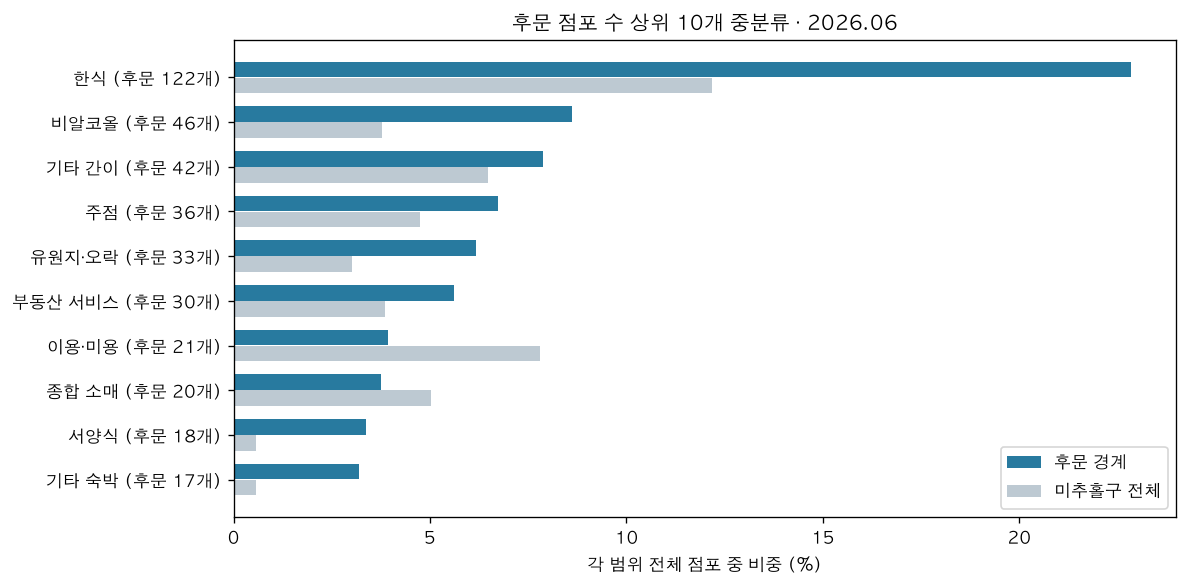

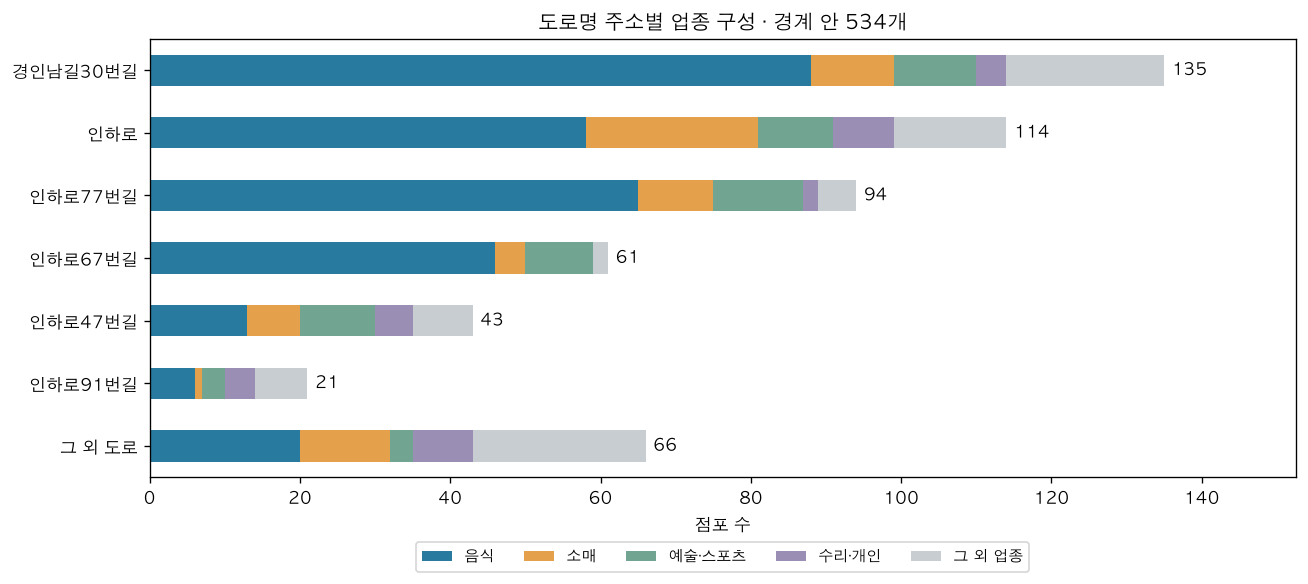

In [5]:
industry=pd.read_csv(ROOT/'outputs/inha/industries_M.csv').head(10).iloc[::-1]
fig,ax=plt.subplots(figsize=(10,5))
y=np.arange(len(industry))
ax.barh(y+.18,industry.store_share*100,height=.35,label='후문 경계',color='#287a9f')
ax.barh(y-.18,industry.district_share*100,height=.35,label='미추홀구 전체',color='#bdc9d2')
ax.set(yticks=y,yticklabels=[f'{n.strip()} (후문 {c}개)' for n,c in zip(industry.indsMclsNm,industry.store_count)],
       xlabel='각 범위 전체 점포 중 비중 (%)',title='후문 점포 수 상위 10개 중분류 · 2026.06')
ax.legend()
figure_done(fig,'industry_comparison.png')

roads=stores.rdnm.fillna('주소 미상').str.replace('인천광역시 미추홀구 ','',regex=False)
top_roads=roads.value_counts().head(6).index.tolist()
road_group=roads.where(roads.isin(top_roads),'그 외 도로')
major=stores.indsLclsNm.value_counts().head(4).index.tolist()
industry_group=stores.indsLclsNm.where(stores.indsLclsNm.isin(major),'그 외 업종')
road_counts=pd.crosstab(road_group,industry_group).reindex(index=top_roads+['그 외 도로'],columns=major+['그 외 업종'],fill_value=0)
assert road_counts.to_numpy().sum()==len(stores)
fig,ax=plt.subplots(figsize=(11,5))
road_counts.plot.barh(stacked=True,ax=ax,color=['#287a9f','#e5a04b','#71a591','#9a8eb4','#c8cdd2'])
ax.invert_yaxis()
ax.set(xlabel='점포 수',ylabel='',title='도로명 주소별 업종 구성 · 경계 안 534개')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.13),ncol=5,fontsize=9)
for i,total in enumerate(road_counts.sum(axis=1)):
    ax.text(total+1,i,str(total),va='center')
ax.set_xlim(0,road_counts.sum(axis=1).max()*1.13)
figure_done(fig,'road_industry_mix.png')


### 배후 주민과 학사일정

주민 연령은 용현1·4동 전체 기준이며 학생·방문객 구성과 다르다. 학사일정 그림은 소비와 비교할 시기 구분이며 수요 감소를 입증하지 않는다.


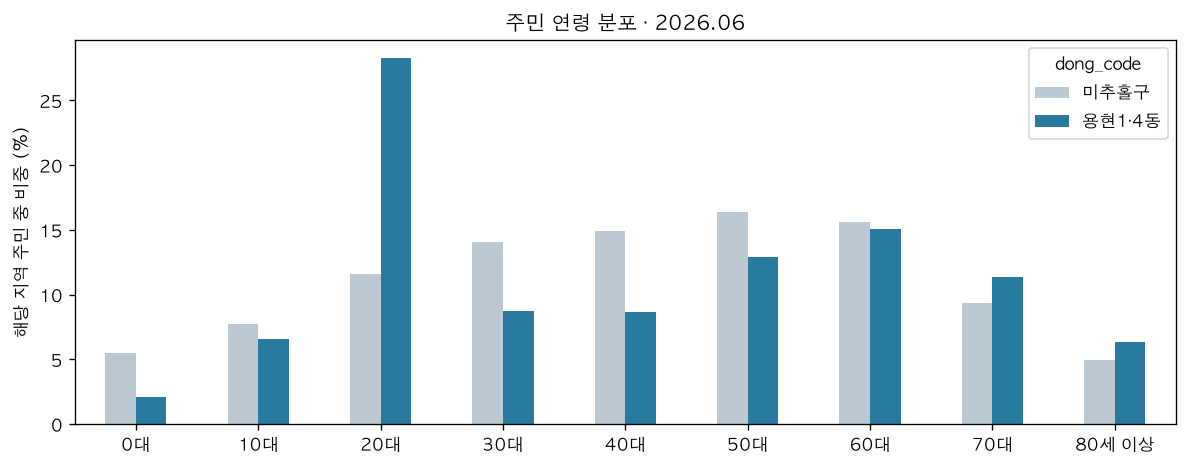

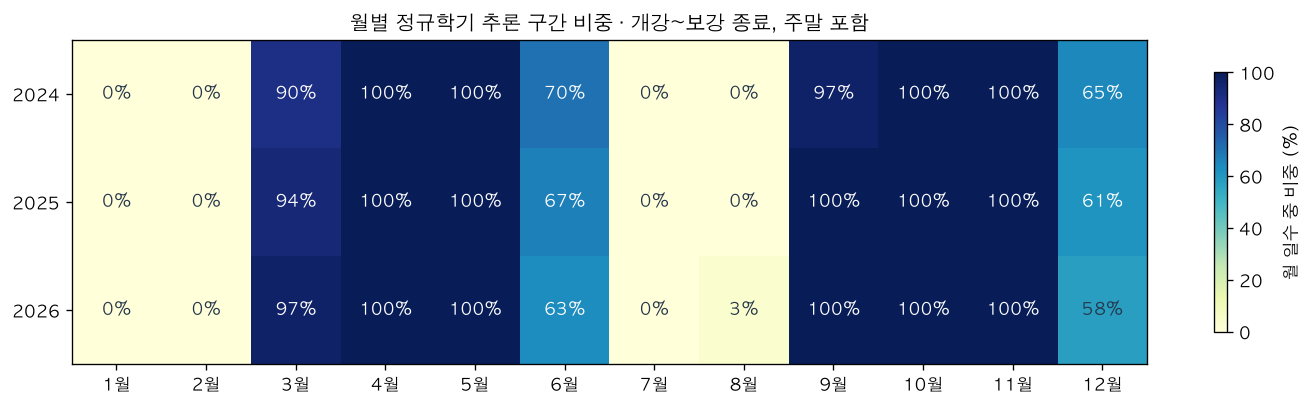

In [6]:
ages=pd.read_csv(ROOT/'outputs/population_age_1year.csv',dtype={'month':str,'dong_code':str})
ages=ages[(ages.month=='202606') & (ages.sex=='계') & ages.dong_code.isin(['2817700000','2817754000'])].copy()
ages['연령대']=np.minimum(ages.age_lower//10*10,80).astype(int)
age_counts=ages.groupby(['연령대','dong_code']).population.sum().unstack().sort_index()
assert age_counts.sum().to_dict()=={'2817700000':418211,'2817754000':17361}
age_share=age_counts.div(age_counts.sum(),axis=1)*100
fig,ax=plt.subplots(figsize=(10,4))
age_share.rename(columns={'2817700000':'미추홀구','2817754000':'용현1·4동'}).plot.bar(ax=ax,color=['#bdc9d2','#287a9f'])
ax.set(xticklabels=[f'{a}대' if a<80 else '80세 이상' for a in age_share.index],
       xlabel='',ylabel='해당 지역 주민 중 비중 (%)',title='주민 연령 분포 · 2026.06')
ax.tick_params(axis='x',rotation=0)
figure_done(fig,'resident_age_comparison.png')

cal=pd.read_csv(ROOT/'outputs/inha/academic_monthly_features.csv',dtype={'month':str})
cal['연도']=cal.month.str[:4]; cal['월']=cal.month.str[4:].astype(int)
matrix=cal.pivot(index='연도',columns='월',values='regular_term_share_inferred')*100
assert matrix.shape==(3,12) and matrix.notna().all().all()
assert ((matrix>=0)&(matrix<=100)).all().all()
fig,ax=plt.subplots(figsize=(12,3.5))
im=ax.imshow(matrix,vmin=0,vmax=100,cmap='YlGnBu',aspect='auto')
for i in range(3):
    for j in range(12):
        v=matrix.iloc[i,j]
        ax.text(j,i,f'{v:.0f}%',ha='center',va='center',color='white' if v>60 else '#25364a')
ax.set(xticks=range(12),xticklabels=[f'{m}월' for m in range(1,13)],yticks=range(3),yticklabels=matrix.index,
       title='월별 정규학기 추론 구간 비중 · 개강~보강 종료, 주말 포함')
fig.colorbar(im,ax=ax,label='월 일수 중 비중 (%)',shrink=.8)
figure_done(fig,'academic_calendar_heatmap.png')


## 3. 카드·유동 데이터

**우선 신청 후보: 신한 소비·가맹점 2종 + LGU 유동 3종.**
기간이 겹치는 2024년을 기본 비교 시점으로 두고, 최신 동향·후문 세부 위치는 별도로 보강한다.

| 후보 | 확인된 제공 기간 | 공간·내용 | 확인할 사항 |
|---|---|---|---|
| SHC_004 신한 지역별매출및이용고객정보 | 2019.01~2026.06 | 읍면동·월·업종·시간·고객속성·금액/건수 | 인천 포함·행정동/법정동 코드, 일별 설명과 월 컬럼 불일치 |
| SHC_003 신한 지역별가맹점정보 | 2019.01~2026.06 | 읍면동·월·업종·가맹점 상태/가동·수 | 상태코드 정의. 개별 점포 명단 아님 |
| LGU_019 요일별 유동 | 2024.01~12, 인천 포함 | 행정동·월·요일·보행/주행 | 합계/평균·중복계수·환산 정의 |
| LGU_020 시간대별 유동 | 2024.01~12, 인천 포함 | 행정동·월·4개 시간대·보행/주행 | 0~9 / 9~12 / 12~18 / 18~24시 |
| LGU_021 성연령별 유동 | 2024.01~12, 인천 포함 | 행정동·월·성·5세 연령대 | 시간·요일과 결합된 교차표는 아님 |

출처: [데이터안심구역 제공 데이터 조회](https://dsz.kdata.or.kr/svc/data/search.do) → 상품명 검색 → 미리보기. 상세 샘플은 부록 B.

**다른 상품을 주자료로 선택하지 않은 이유**

- BC는 매장랜덤번호가 있는 상품도 있지만 2019년 자료이고 위치 연결표가 없다.
- 삼성–이마트24는 맥주 등 품목·수량이 있으나 2020~2021년 특정 체인·카드 자료다.
- 나이스 ‘주요상권 유동·매출’은 서울 대상이다. 설명의 50m 셀이 실제 제공 컬럼에 있다는 뜻은 아니다.
- LGU 요일·시간·연령 자료는 각각의 분포다. 합쳐서 ‘금요일 저녁 20대’를 만들 수 없다.


## 4. 공개데이터

| 자료 | 지금 상태 | 다음 활용 | 실물 샘플 |
|---|---|---|---|
| 점포·업종 | 2026.06 보유 | 과거 동일 경계와 비교 | 부록 A-1 |
| 버스 승하차·위치 | 2026.06 / 2025.10 보유 | 과거 월자료로 진입 여건 보강 | A-2 |
| 주민등록인구 | 2026.06·08 보유 | 2024 비교에는 같은 해 자료 추가 | A-3 |
| 학사일정 | 2024~2026 수집 | 학기·시험·계절학기 변동 검토 | A-4 |
| 날씨 | 인천 관측소 2024.06 실제 30일 확보 | 필요한 기간으로 확대 | A-5 |
| 공휴일 | 공식 API 명세 확인, 실제 응답 미수집 | 일·월별 휴일 구분 | 아직 실물 없음 |
| 개폐업 | 경로 확인, 원문 서버 403으로 미확보 | 점포 변화가 관측될 때 보강 | 아직 실물 없음 |
| 공중·개방화장실 | 2026.07.31 기준 72건 확보 | 답사에서 위치·개방시간 확인 | A-6 |

### 추가 확보 우선순위

| 우선순위 | 추가 데이터 | 확인할 문제·활용 |
|---|---|---|
| 1 | [과거 상가업소 파일](https://www.data.go.kr/data/15083033/fileData.do)·인허가 개폐업 원문 | 동일 경계의 점포·업종 변화. 목록에서 사라진 점포는 폐업 자료로 재확인 |
| 2 | 같은 기간의 월별 버스·주민인구 | 방문 여건·배후 수요의 변화. 계절성과 장기 변화를 분리 |
| 3 | 구청·상인회의 기존 지원사업 위치·기간·대상 | 이미 시행한 조치와 겹치는지, 비교 가능한 사전·사후 기간이 있는지 확인 |
| 현장 불편 확인 후 | [공영주차장](https://www.michuhol.go.kr/main/content.do?sq=393)·공중화장실·영업시간 | 주차·편의시설 부족을 먼저 단정하지 않고 인터뷰와 함께 개선 위치 검토 |

과거 점포·사업 이력·주차장 원본은 아직 미확보다. 현재의 단면 자료에 변화를 보여주는 자료를 더하는 것이 우선이다.

**최신 열람 서비스와 오래된 공개파일을 구별한다.**

- [소상공인365](https://bigdata.sbiz.or.kr/#/apiMain/commercialGuide/2): 2026.06 유동·추정 매출 안내 확인. 후문 상세 결과·다운로드는 미확인. 안내상 연구 이용 조건 확인 필요.
- [인천 도로 주변 유동](https://www.data.go.kr/data/15095901/fileData.do): 택시 IoT 좌표 자료지만 **2021년 기준**. 원본 미수집.
- [인천 소비 데이터](https://www.data.go.kr/data/15076578/fileData.do): **2016.12~2020.06 구 단위·분기**. 원본 미수집.
- [코레일 시간대별 수송통계](https://info.korail.com/info/selectBbsNttView.do?bbsNo=425&key=867&nttNo=26267): 공식 첨부 목록 확인, 원본 및 인하대역 행은 미검증. 역 전체 이용을 후문 방문으로 보지 않는다.


## 5. 분석 계획

| 답할 질문 | 분석표·그림 | 필요한 근거 | 전략으로 연결하는 조건 |
|---|---|---|---|
| 소비는 언제·어떤 업종에서 발생하는가? | 월별 금액·건수·건당 금액·전년 동월 변화 | 신한 본자료 | 반복되는 강점/부진의 업종·시기 식별 |
| 유동과 소비는 어느 시간대에 집중되는가? | 각 자료의 시간대 분포 | LGU+신한, 공통 시간구간 | 실제 수요와 영업·서비스 불일치 현장 확인 |
| 요일·연령별 이용은 어떻게 다른가? | 요일 유동, 연령 유동/소비를 별도로 비교 | LGU 3종·신한 | 고객·방문 목적 조사와 함께 타깃 검토 |
| 공급 규모가 변했는가? | 가맹점 상태/수와 소비 변화 | 신한 가맹점·과거 공공 점포 | 카드 해지와 실제 폐업 구별 |
| 어느 골목을 개선해야 하는가? | 고정 지점 통행·영업·불편 지도 | 후문 현장 관찰·이용자 의견 | 구간·반복성·이용 수요가 확인된 조치 |

**조사 계획안:** 진입부 A / 중심거리 B / 내부 골목 C에서 평일 2일+토요일 1일, 점심·저녁 동일 시간 길이 관찰.
3지점×3일×2시간대=18개 관찰 기록. 야간 전략을 검토하면 해당 늦은 시간대 조사 추가.
상인 10~15곳·이용자 20~30명 인터뷰는 탐색용이며 대표 표본이 아니다.

**최종 산출물:** 근거 있는 전략 2~3개에 **구간·시간·대상 / 조치 / 실행 주체 / 비용·제약 / 사전·사후 지표**를 명시한다.

**시점 주의:** 2024년 유동과 2026년 현장은 같은 시점이 아니다. 소비는 별도 장기 추세로 보고, 동일 시점 자료끼리 우선 비교한다.


## 6. 협의사항

| 항목 | 제안하는 방향 | 협의할 내용 |
|---|---|---|
| 분석 범위 | 직접 설정한 후문 경계 유지 | 포함·제외 골목과 점포 입구 확인, 경계 설정 이유 기록 |
| 데이터 구성 | 신한 2종+LGU 3종을 우선 후보로 | 인천 포함·동 코드·2025~2026 유동·맞춤 경계 집계 가능성 |
| 분석 시점 | 2024 공통 EDA + 최신 소비·현장 보강 | 과거 패턴과 현재 전략을 연결하는 범위에 동의하는가? |
| 구청 협조 | 기존 사업·가능한 지원 수단 파악 | 사업명·위치·기간, 상인회 연결, 활용 가능한 유동/소비 자료 |
| 현장조사 | A/B/C 지점 답사 후 고정 | 조사 인원·시간과 상인/이용자 접촉 가능 여부 |

### 안심구역 확인사항

1. “SHC_003/004에 인천 자료가 포함되며, UMD_CD는 행정동인가요, 법정동인가요?”
2. “SHC_004 설명에는 일별이라고 되어 있는데 샘플에는 월만 있습니다. 날짜·요일 자료가 별도로 있나요?”
3. “LGU 2024년 이후 자료 또는 사용자 GeoJSON 경계의 카드·유동 집계가 가능한가요?”
4. “유동 값은 월 합계인가요, 요일·시간대별 평균인가요? 중복·환산·소수집계 처리는 어떻게 하나요?”

### 다음 단계

**데이터 제공 범위 확인과 첫 답사 병행 → 실제 유동·소비 EDA → 필요한 원인 자료 보강 → 전략 2~3개와 평가계획.**


---
# 부록 A. 공개데이터 실물 샘플

아래는 **현재 프로젝트가 보유한 실제 공개자료에서 발췌한 행**이다. 대표 표본·추정 모집단이 아니다.
CSV는 [첨부 폴더](outputs/meeting_20260916/samples/)에 저장한다. 원본 필드명을 유지하고, 화면에서는 일부 컬럼만 보여준다.


## A-1. 점포·업종 · 2026.06

출처: [소상공인시장진흥공단 상가정보](https://www.data.go.kr/data/15012005/openapi.do).
**선정 방식:** 후문 경계 내부 점포를 공공 점포 ID 순으로 정렬한 첫 10행. 공실·폐업 목록이 아니다.


In [5]:
store_cols=['bizesId','bizesNm','indsLclsNm','indsMclsNm','indsSclsNm','adongCd','adongNm','rdnmAdr','lon','lat']
sample_stores = attach(stores.sort_values('bizesId')[store_cols].head(10),'public_stores_202606.csv',
    '후문 점포 실제 발췌','https://www.data.go.kr/data/15012005/openapi.do','outputs/inha/stores.csv',
    '2026.06','REAL_PUBLIC_EXCERPT','경계 안 점포 ID순 첫 10행; 대표 표본 아님')
table(sample_stores[['bizesNm','indsSclsNm','adongNm','rdnmAdr','lon','lat']].head(5).assign(lon=lambda d:d.lon.map('{:.6f}'.format),lat=lambda d:d.lat.map('{:.6f}'.format)))


bizesNm,indsSclsNm,adongNm,rdnmAdr,lon,lat
웨일하우스,백반/한정식,용현1.4동,인천광역시 미추홀구 인하로77번길 18-1,126.657513,37.451866
신참떡볶이,김밥/만두/분식,용현1.4동,인천광역시 미추홀구 인하로67번길 10,126.656191,37.451871
엘루새,독서실/스터디 카페,용현1.4동,인천광역시 미추홀구 인하로91번길 55,126.660985,37.451381
타이쿤보드게임카페,기타 오락장,용현1.4동,인천광역시 미추홀구 경인남길30번길 49,126.657141,37.451811
비케이씨시스템,사무기기 소매업,용현1.4동,인천광역시 미추홀구 인하로77번길 28,126.658461,37.452365


## A-2. 버스 승하차와 정류장 위치

출처: [인천 정류장별 이용승객](https://www.data.go.kr/data/15048264/fileData.do) · [전국 버스정류장 위치](https://www.data.go.kr/data/15067528/fileData.do).
**선정 방식:** ‘인하대후문’이라는 이름이 있는 원본 행. 승하차는 2026.06, 위치 원본은 2025.10 기준이다.
두 파일은 별도로 첨부한다. 승하차 합은 고유 방문자 수가 아니다.


In [6]:
bus_meta=json.loads((ROOT/'data/raw/bus_stop.json').read_text())
bus_raw=pd.DataFrame(bus_meta['rows'])
bus_sample=attach(bus_raw[bus_raw['정류장명'].str.contains('인하대후문',na=False)],
    'public_bus_usage_202606.csv','후문 명칭 정류장 승하차 원본 발췌',
    'https://www.data.go.kr/data/15048264/fileData.do','data/raw/bus_stop.json','2026.06',
    'REAL_PUBLIC_EXCERPT','정류장명에 인하대후문 포함')
loc_meta=json.loads((ROOT/'data/raw/bus_location_incheon.json').read_text())
loc_raw=pd.DataFrame(loc_meta['rows'])
loc_sample=attach(loc_raw[loc_raw['정류장명'].str.contains('인하대후문',na=False)],
    'public_bus_location_202510.csv','후문 명칭 정류장 위치 원본 발췌',
    'https://www.data.go.kr/data/15067528/fileData.do','data/raw/bus_location_incheon.json','2025.10',
    'REAL_PUBLIC_EXCERPT','정류장명에 인하대후문 포함; 운영기관별 번호 체계 구분 필요')
assert len(bus_sample)>0 and len(loc_sample)>0
table(bus_sample)
table(loc_sample[['정류장명','모바일단축번호','위도','경도','정보수집일']])


승차인원수,승차인원수(카드),승차인원수(현금),일평균 승하차인원수,정류장 번호,정류장명,하차인원수,하차인원수(카드)
49870,49870,0,1843.87,37165,인하대후문,5446,5446
6758,6758,0,333.80,37166,인하대후문,3256,3256
12599,12599,0,2234.50,37167,인하대후문,54436,54436


정류장명,모바일단축번호,위도,경도,정보수집일
인하대후문,37166,37.45096670,126.6570500,2025-10-31
인하대후문,37167,37.45145000,126.6561167,2025-10-31
인하대후문,37165,37.45135200,126.6557200,2025-10-31
인하대후문,37166,37.45088000,126.6574890,2025-10-31
인하대후문,37167,37.45146300,126.6561430,2025-10-31


## A-3. 주민등록인구 · 2026.06·08

출처: [행정안전부 연령별 인구현황](https://jumin.mois.go.kr/ageStatMonth.do).
**선정 방식:** 두 시점의 용현1·4동. 원본을 정규화·집계한 실제 값이며 동 전체 주민이다.
20~39세 주민을 학생 수나 상권 고객 수로 해석하지 않는다. 두 달로 장기 추세를 판단하지 않는다.


In [7]:
pop=pd.read_csv(ROOT/'outputs/population_dong_summary.csv',dtype={'dong_code':str,'month':str})
pop_sample=attach(pop[pop.dong_code.eq('2817754000')],'public_population_context_202606_08.csv',
    '용현1·4동 주민등록인구 실제 집계','https://jumin.mois.go.kr/ageStatMonth.do',
    'outputs/population_dong_summary.csv','2026.06 / 2026.08','REAL_PUBLIC_DERIVED','두 월의 용현1·4동 전체')
table(pop_sample[['month','region_name','total_population','age_20_39','age_20_39_pct','age_65_plus','age_65_plus_pct']])


month,region_name,total_population,age_20_39,age_20_39_pct,age_65_plus,age_65_plus_pct
202606,인천광역시 미추홀구 용현1.4동,17361,6428,37.03,4422,25.47
202608,인천광역시 미추홀구 용현1.4동,17171,6328,36.85,4453,25.93


## A-4. 학사일정 · 실제 일정과 분석용 월 변수

출처: [인하대학교 연도별 학사일정](https://www.inha.ac.kr/kr/1908/subview.do).
2024년 6월과 겹치는 시험·보강·계절학기 일정을 발췌했다. 추가 CSV에는 2024년 12개월의 분석용 변수를 첨부한다.
**정규학기 비중은 개강~보강 종료로 추론한 구간 비중**으로, 주말을 포함하며 실제 등교일 수가 아니다.


In [8]:
events=pd.read_csv(ROOT/'outputs/inha/academic_events_2024_2026.csv')
selected=events[(events.start_date<='2024-06-30') & (events.end_date>='2024-06-01')]
calendar_sample=attach(selected,'public_inha_events_202406.csv','공식 학사일정 실제 발췌',
    'https://www.inha.ac.kr/kr/1908/subview.do','outputs/inha/academic_events_2024_2026.csv',
    '2024.06과 겹치는 일정','REAL_PUBLIC_DERIVED','날짜 정규화; 6월과 기간이 겹치는 공식 일정')
monthly_calendar=pd.read_csv(ROOT/'outputs/inha/academic_monthly_features.csv',dtype={'month':str})
calendar_features=attach(monthly_calendar[monthly_calendar.month.str.startswith('2024')],
    'derived_inha_calendar_2024.csv','학사일정 분석용 월 변수','https://www.inha.ac.kr/kr/1908/subview.do',
    'outputs/inha/academic_monthly_features.csv','2024.01~12','REAL_PUBLIC_DERIVED',
    '정규학기 구간은 추론값; 공식 수업일·학생 출석 아님')
table(calendar_sample[['start_date','end_date','title','event_type']])
table(calendar_features[['month','regular_term_span_inferred_days','seasonal_class_days','regular_term_share_inferred']].head(6))


start_date,end_date,title,event_type
2024-06-10,2024-06-14,2024-1학기 기말고사,final_exam
2024-06-17,2024-06-21,2024-1학기 보강주간 *이러닝 기말고사 : 6. 19.(수) ~ 20.(목) 주간,makeup
2024-06-24,2024-07-17,2024학년도 하계 계절학기 수업,seasonal_class


month,regular_term_span_inferred_days,seasonal_class_days,regular_term_share_inferred
202401,0,10,0.00
202402,0,0,0.00
202403,28,0,0.90
202404,30,0,1.00
202405,31,0,1.00
202406,21,7,0.70


## A-5. 기상청 인천 관측소 · 2024년 6월 실제 관측

출처: [기상청 날씨누리 인천(112) 2024.06](https://www.weather.go.kr/w/weather/land/past-obs/obs-by-day.do?stn=112&yy=2024&mm=6&obs=1).
**이번에 실제 조회한 30일 전체**를 CSV로 첨부한다. 인하대 후문 내부의 센서 관측은 아니다.
기온 단위는 ℃, 강수량은 mm다. 강수량의 **`-`는 원문대로 보존**하며 0으로 대체하지 않는다. 본분석은 ASOS 자료의 결측·무강수 정의와 관측소 위치를 확인한 후 진행한다.


In [9]:
weather_raw=json.loads((ROOT/'data/raw/kma_incheon_202406_public_sample.json').read_text())
assert dict(weather_raw['selection']) == {'stn':'112','yy':'2024','mm':'6','obs':'1'}
rows=weather_raw['tables'][0]['rows']
weather_rows=[]
for i in range(1,len(rows),2):
    assert len(rows[i])==len(rows[i+1])==7
    for day,body in zip(rows[i],rows[i+1]):
        if not re.fullmatch(r'\d+일',day.strip()):
            continue
        fields=dict(line.split(':',1) for line in body.strip().splitlines() if ':' in line)
        def temp(key):
            return float(fields[key].replace('℃','').strip())
        weather_rows.append({'date':f"2024-06-{int(day.strip()[:-1]):02d}",'station_id':'112',
            'station_name':'인천','mean_temp_c':temp('평균기온'),'max_temp_c':temp('최고기온'),
            'min_temp_c':temp('최저기온'),'rainfall_raw':fields['일강수량'].strip(),
            'source_url':weather_raw['source_url']})
weather=pd.DataFrame(weather_rows).sort_values('date')
assert len(weather)==30 and weather.date.is_unique
assert set(weather.date)==set(pd.date_range('2024-06-01','2024-06-30').strftime('%Y-%m-%d'))
assert ((weather.min_temp_c<=weather.mean_temp_c)&(weather.mean_temp_c<=weather.max_temp_c)).all()
assert weather.loc[weather.date.eq('2024-06-01'),'mean_temp_c'].iloc[0]==19.3
assert weather.loc[weather.date.eq('2024-06-08'),'rainfall_raw'].iloc[0]=='9.9mm'
attach(weather,'public_weather_incheon_202406.csv','인천 관측소 실제 일별 관측',
    weather_raw['source_url'],'data/raw/kma_incheon_202406_public_sample.json','2024.06.01~30',
    'REAL_PUBLIC_EXCERPT','공식 월 달력 전체 30일; 화면 표를 날짜별 정규화')
table(weather.drop(columns='source_url').head(10))


date,station_id,station_name,mean_temp_c,max_temp_c,min_temp_c,rainfall_raw
2024-06-01,112,인천,19.30,23.50,16.70,-
2024-06-02,112,인천,19.20,22.70,16.00,-
2024-06-03,112,인천,21.70,27.00,15.80,-
2024-06-04,112,인천,22.30,26.40,18.40,-
2024-06-05,112,인천,21.00,25.20,17.70,-
2024-06-06,112,인천,21.00,26.60,18.00,-
2024-06-07,112,인천,21.00,25.10,17.00,0.1mm
2024-06-08,112,인천,19.70,23.10,17.70,9.9mm
2024-06-09,112,인천,20.80,24.80,17.50,-
2024-06-10,112,인천,22.80,27.90,18.90,-


## A-6. 공중·개방화장실 · 2026.07.31

출처: [미추홀구 공중및개방화장실현황](https://www.data.go.kr/data/15071405/fileData.do).
공식 CSV 전체 72건을 첨부했다. 아래는 원본 좌표상 후문 경계 중심에 가까운 5곳이다.
직선거리는 도보 거리가 아니며, 시설 목록에는 개방시간이 없다. 구 전체 자료에 서로 다른 주소의 좌표 중복이 있어 위치·이용 가능 여부는 답사에서 확인한다. 목록만으로 화장실 부족을 판단하지 않는다.


In [10]:
toilets=pd.read_csv(ROOT/'data/raw/michuhol_public_toilets_20260731.csv')
assert len(toilets)==72 and toilets['연번'].is_unique
assert toilets['데이터기준일자'].eq('2026-07-31').all()
attach(toilets,'public_toilets_michuhol_20260731.csv','미추홀구 공중·개방화장실 전체',
    'https://www.data.go.kr/data/15071405/fileData.do','data/raw/michuhol_public_toilets_20260731.csv',
    '2026.07.31','REAL_PUBLIC_EXCERPT','공식 첨부 CSV 72행 전체; 문자 인코딩만 UTF-8로 변환')
center=ring[:-1].mean(axis=0)
toilets['경계 꼭짓점 평균까지 직선거리(m)']=np.hypot(
    (toilets['경도']-center[0])*111320*np.cos(np.deg2rad(center[1])),
    (toilets['위도']-center[1])*111320).round()
table(toilets.nsmallest(5,'경계 꼭짓점 평균까지 직선거리(m)')[
    ['명칭','도로명주소','구분','경계 꼭짓점 평균까지 직선거리(m)']])


명칭,도로명주소,구분,경계 꼭짓점 평균까지 직선거리(m)
용남공원,인천광역시 미추홀구 경인남길102번길135,공중(공원),628.00
수봉공원(망배단),인천광역시 미추홀구 수봉남로24번길 27,공중(공원),642.00
수봉공원(유아숲체험원),인천광역시 미추홀구,공중(공원),751.00
용현시장(상),인천광역시 미추홀구 인주대로153번길 38-1,공중(시장),836.00
인하대역CGV타워,인천광역시 미추홀구 매소홀로 255(학익동),개방,952.00


---
# 부록 B. 안심구역 공개 미리보기 샘플

**아래는 합성 데이터가 아니라 사이트가 공개한 마스킹 미리보기다.** `*`가 있는 값은 그대로 보존한다.
원자료의 분포·후문 매출·인천 표본 수를 검증할 수 없다. 표본의 지역은 인천이 아닐 수도 있다.
23개 상품의 공개 10행을 CSV로 첨부했다. 아래 표는 핵심 상품의 주요 컬럼이다.

출처: [KDATA 제공 데이터 조회](https://dsz.kdata.or.kr/svc/data/search.do). 확인일 2026.09.15.


In [11]:
for item in products.values():
    names=[c['name'] for c in item['columns']]
    frame=pd.DataFrame(item['samples']).reindex(columns=names)
    attach(frame,f"preview_{item['id']}_MASKED.csv",item['name'],
        'https://dsz.kdata.or.kr/svc/data/search.do','data/raw/dsz_catalog_sample_audit_20260915.json',
        item['description'],'MASKED_PUBLIC_PREVIEW','사이트 공개 10행, 마스킹 유지; 지역 대표 표본 아님')

def preview(pid, columns):
    p=products[pid]
    display(Markdown(f"### {pid} · {p['name']}\n{p['description']}"))
    labels={c['name']:c['label'] for c in p['columns']}
    table(pd.DataFrame({'필드':columns,'뜻':[labels[c] for c in columns]}))
    table(pd.DataFrame(p['samples'])[columns].head(3))

preview('SHC_004',['STD_YM','UMD_CD','TOBU_MEDVS_CD','TIZO_CLCD','N10_UNIT_AGE_CLCD','PAYM_NOCA','PAYM_AMT'])
preview('SHC_003',['STD_YM','UMD_CD','TOBU_MEDVS_CD','FRNC_STAT_CD','OPER_CD','FRNC_CNT'])


### SHC_004 · 지역별매출및이용고객정보
지역별 매출 및 이용고객 정보(2019년 1월~2026년 6월)

필드,뜻
STD_YM,기준년월
UMD_CD,읍면동코드
TOBU_MEDVS_CD,업종중분류코드
TIZO_CLCD,시간대구분코드
N10_UNIT_AGE_CLCD,십단위연령구분코드
PAYM_NOCA,결제건수
PAYM_AMT,결제금액


STD_YM,UMD_CD,TOBU_MEDVS_CD,TIZO_CLCD,N10_UNIT_AGE_CLCD,PAYM_NOCA,PAYM_AMT
201***,41113*****,23,01,04,10,57
201***,41113*****,23,01,03,22,3**
201***,41113*****,37,01,03,42,4**


### SHC_003 · 지역별가맹점정보
지역별, 가맹점 정보(2019년 1월~2026년 6월)

필드,뜻
STD_YM,기준년월
UMD_CD,읍면동코드
TOBU_MEDVS_CD,업종중분류코드
FRNC_STAT_CD,가맹점상태코드
OPER_CD,가동코드
FRNC_CNT,가맹점수


STD_YM,UMD_CD,TOBU_MEDVS_CD,FRNC_STAT_CD,OPER_CD,FRNC_CNT
201***,11110*****,71,03,02,2
201***,11110*****,72,03,01,10
201***,11110*****,73,03,01,2


**신한 샘플 해석:** `STD_YM`은 월, `UMD_CD`는 읍면동 코드다. 정확한 코드 정의는 별도 확인이 필요하다.
가맹점명·ID·주소·좌표가 없으므로 후문 다각형으로 매출을 직접 필터할 수 없다. 가맹점 수는 등록·해지 상태 코드 정의에 따라 집계한다.


In [12]:
preview('LGU_019',['BASE_MM','ADNG_CD','DOW','WALK_POPL_CNT','NTWK_POPL_CNT'])
preview('LGU_020',['BASE_MM','ADNG_CD','TMZN','WALK_POPL_CNT','NTWK_POPL_CNT'])
preview('LGU_021',['BASE_MM','ADNG_CD','TYPE','M4_SUM','M5_SUM','FM4_SUM','FM5_SUM','SUM_TOTAL'])


### LGU_019 · 7대광역시 요일별 유동인구 데이터
7대광역시 요일별 유동인구 데이터(2024년 1월~2024년 12월)

필드,뜻
BASE_MM,기준일자
ADNG_CD,행정동코드
DOW,요일
WALK_POPL_CNT,보행인구
NTWK_POPL_CNT,주행인구


BASE_MM,ADNG_CD,DOW,WALK_POPL_CNT,NTWK_POPL_CNT
202***,2611****,금,38**,12**
202***,2611****,목,38**,11**
202***,2611****,수,38**,11**


### LGU_020 · 7대광역시 시간대별 유동인구 데이터
7대광역시 시간대별 유동인구 데이터(2024년 1월~2024년 12월)

필드,뜻
BASE_MM,기준일자
ADNG_CD,행정동코드
TMZN,시간대
WALK_POPL_CNT,보행인구
NTWK_POPL_CNT,주행인구


BASE_MM,ADNG_CD,TMZN,WALK_POPL_CNT,NTWK_POPL_CNT
202***,2611****,1,16**,6**
202***,2611****,2,48**,16**
202***,2611****,3,62**,19**


### LGU_021 · 7대광역시 성연령별 유동인구 데이터
7대광역시 성연령별 유동인구 데이터(2024년 1월~2024년 12월)

필드,뜻
BASE_MM,기준일자
ADNG_CD,행정동코드
TYPE,유동인구_구분
M4_SUM,남성20~24세
M5_SUM,남성25~29세
FM4_SUM,여성20~24세
FM5_SUM,여성25~29세
SUM_TOTAL,소계(남녀합계)


BASE_MM,ADNG_CD,TYPE,M4_SUM,M5_SUM,FM4_SUM,FM5_SUM,SUM_TOTAL
202***,2611****,1,1**,1**,1**,2**,34**
202***,2611****,2,34,41,34,46,11**
202***,2611****,1,24,31,31,35,7**


**LGU 샘플 해석:** 019에는 요일, 020에는 시간대, 021에는 연령이 있다. 세 파일에 공통으로 월·동이 있다고 해서
한 사람의 요일·시간·연령이 연결되는 것은 아니다. 021의 `TYPE` 코드, `SUM_TOTAL` 집계 정의도 확인해야 한다.


In [13]:
preview('BCC_001',['STD_YM','STD_DAY','SHOP_RNDM_NO','TIME_CLCD','SALE_AMT'])
preview('SSC_003',['CRI_YM','HJ_DONG','STORE_CD','DAY','P_L_NAME','P_M_NAME','P_QT'])


### BCC_001 · 고객별소비분석
업종, 시간대별 소비경로 파악(2019년 7월~12월)

필드,뜻
STD_YM,기준년월
STD_DAY,기준일자
SHOP_RNDM_NO,매장랜덤번호
TIME_CLCD,시간구분코드
SALE_AMT,매출금액


STD_YM,STD_DAY,SHOP_RNDM_NO,TIME_CLCD,SALE_AMT
201***,2019****,9B97A8A422**********,16,44**
201***,2019****,9B97A86B79**********,11,12***
201***,2019****,9B97A8B0AB**********,14,163***


### SSC_003 · 삼성카드-이마트24 결합데이터
전국 삼성카드-이마트24 결합데이터(2020년 6월~2021년 5월)

필드,뜻
CRI_YM,매출년월
HJ_DONG,가맹점_소재_행정동
STORE_CD,점포번호
DAY,매출발생요일
P_L_NAME,제품대분류코드명
P_M_NAME,제품중분류코드명
P_QT,제품수량


CRI_YM,HJ_DONG,STORE_CD,DAY,P_L_NAME,P_M_NAME,P_QT
202***,대**,69**,Sun***,주류,맥주,1
202***,안양**,77**,Wedn*****,조**,샌드**,1
202***,목**,25**,Thur****,주류,맥주,4


**대안 상품 샘플 해석:** BC 매장번호는 위치를 알려주지 않는다. 삼성–이마트24는 제품 분류가 있지만 특정 체인·과거 기간이다.

## 부록 C. 첨부 파일과 출처 확인

각 CSV의 출처 URL·원본 경로·기준시점·발췌 방법·해시를 manifest에 기록했다.
실물 없는 공휴일·개폐업·코레일·오래된 인천 유동/소비 후보에는 임의 샘플을 만들지 않았다.


In [14]:
manifest={'meeting_date':'2026-09-16','prepared_date':'2026-09-15',
    'notebook':'meeting_20260916_inha.ipynb','attachments':attachments,
    'not_acquired':['공휴일 실제 API 응답','개폐업 원문','코레일 첨부 원본',
                    '인천 2021 도로유동 원본','인천 2016~2020 소비 원본','소상공인365 후문 상세 결과'],
    'notes':['마스킹 미리보기는 본자료가 아님','현재 카드·통신 본자료 미확보','합성 결제값 사용 안 함']}
(OUT/'sample_manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding='utf-8')
index=pd.DataFrame(attachments)
index.to_csv(OUT/'sample_index.csv',index=False,encoding='utf-8-sig')
readme=['# 2026.09.16 미팅 첨부자료','',
        '노트북: 프로젝트 루트의 meeting_20260916_inha.ipynb. 결과 저장 완료, 열람에는 재실행 불필요.',
        '재실행은 프로젝트 전체 자료와 .venv가 필요합니다. 샘플만으로 전체 현황을 다시 계산하지 않습니다.',
        '', '## 파일 구분','',
        '- public_: 실제 공개자료 발췌 또는 명시된 정규화 결과.',
        '- derived_: 실제 학사일정을 분석용으로 가공한 값.',
        '- preview_*_MASKED: 안심구역 사이트 공개 10행, 별표 유지. 실제 지역 진단 불가.',
        '- sample_manifest.json / sample_index.csv: 출처·선정방식·기준시점·해시.',
        '', '## 첨부 목록','']
readme += [f"- [{a['file']}]({a['file']}): {a['title']} / {a['rows']}행 / {a['status']}" for a in attachments]
(OUT/'README.md').write_text('\n'.join(readme)+'\n',encoding='utf-8')
for a in attachments:
    frame=pd.read_csv(OUT/a['file'],dtype=str,keep_default_na=False)
    assert len(frame)==a['rows'] and len(frame)>0
    assert hashlib.sha256((OUT/a['file']).read_bytes()).hexdigest()==a['sample_sha256']
assert len(attachments)==31
assert sum(a['rows'] for a in attachments if a['status']=='MASKED_PUBLIC_PREVIEW')==230
table(index[['title','rows','status','file']])


title,rows,status,file
후문 점포 실제 발췌,10,REAL_PUBLIC_EXCERPT,samples/public_stores_202606.csv
후문 명칭 정류장 승하차 원본 발췌,3,REAL_PUBLIC_EXCERPT,samples/public_bus_usage_202606.csv
후문 명칭 정류장 위치 원본 발췌,5,REAL_PUBLIC_EXCERPT,samples/public_bus_location_202510.csv
용현1·4동 주민등록인구 실제 집계,2,REAL_PUBLIC_DERIVED,samples/public_population_context_202606_08.csv
공식 학사일정 실제 발췌,3,REAL_PUBLIC_DERIVED,samples/public_inha_events_202406.csv
학사일정 분석용 월 변수,12,REAL_PUBLIC_DERIVED,samples/derived_inha_calendar_2024.csv
인천 관측소 실제 일별 관측,30,REAL_PUBLIC_EXCERPT,samples/public_weather_incheon_202406.csv
미추홀구 공중·개방화장실 전체,72,REAL_PUBLIC_EXCERPT,samples/public_toilets_michuhol_20260731.csv
지역별가맹점정보,10,MASKED_PUBLIC_PREVIEW,samples/preview_SHC_003_MASKED.csv
지역별매출및이용고객정보,10,MASKED_PUBLIC_PREVIEW,samples/preview_SHC_004_MASKED.csv
